Visualizing the business insights :


In [1]:
import pandas as pd 
import psycopg2 
import matplotlib.pyplot as plt
# connecting the database :
 
conn = psycopg2.connect(
    database="food_demand",
    user="postgres",
    password="rahul@456",
    host="localhost",
    port="5432"
)

pulling queries


C:\Users\rahul\AppData\Local\Temp\ipykernel_22156\2101248967.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


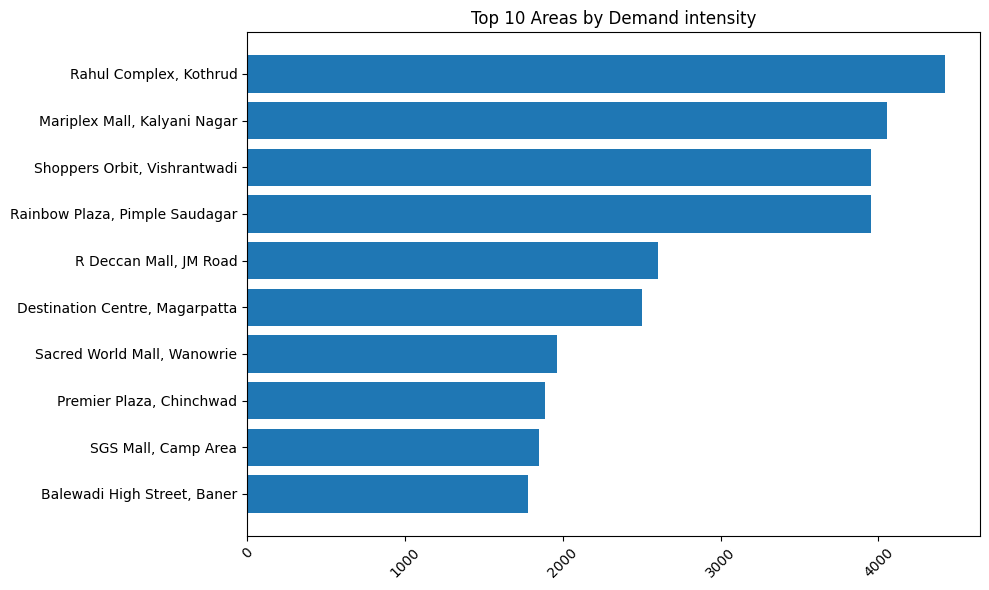

In [2]:
# TOP 10 supply vs demand efficency :

query = """
        SELECT area ,COUNT(*) AS supply, AVG(delivery_reviews) AS demand_intensity 
FROM restaurants 
GROUP BY area 
ORDER BY demand_intensity DESC ;
"""

df = pd.read_sql(query,conn)



top_10 = df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10['area'], top_10['demand_intensity'])
plt.xticks(rotation=45)
plt.title("Top 10 Areas by Demand intensity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


C:\Users\rahul\AppData\Local\Temp\ipykernel_22156\2088160717.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


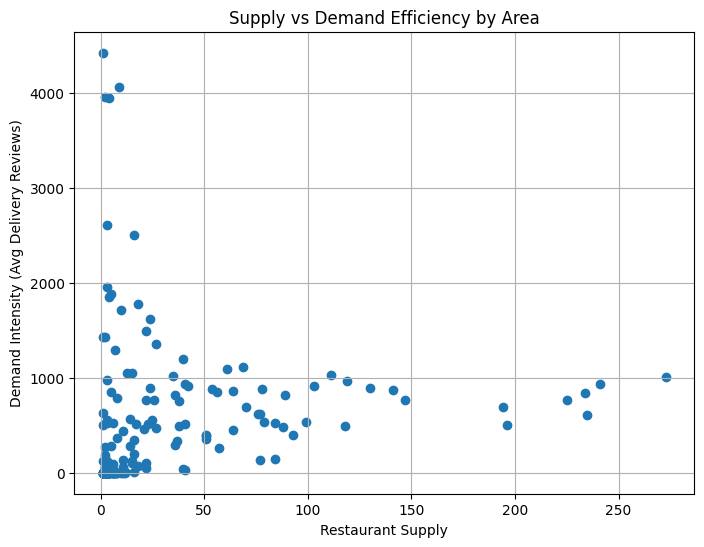

In [ ]:
## Supply vs Demand Efficiency :
query = """ 
        SELECT area ,COUNT(*) AS supply, AVG(delivery_reviews) AS demand_intensity 
FROM restaurants 
GROUP BY area 
ORDER BY demand_intensity DESC ;
                 """
df = pd.read_sql(query,conn)
plt.figure(figsize=(8,6))

plt.scatter(df['supply'], df['demand_intensity'])

plt.xlabel("Restaurant Supply")
plt.ylabel("Demand Intensity (Avg Delivery Reviews)")
plt.title("Supply vs Demand Efficiency by Area")

plt.grid(True)
plt.show()
